In [4]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from itertools import permutations
from sklearn.model_selection import train_test_split

In [18]:
# Define the dataset paths
folders = [
    '/Volumes/Elements/BDI/projects/GSG/outputs/o2_embeddings/ICGCC/model_resnet_icgcc_raw_FTL_0/',
    '/Volumes/Elements/BDI/projects/GSG/outputs/o2_embeddings/ICGCC/model_resnet_icgcc_raw_FTL_25/',
    '/Volumes/Elements/BDI/projects/GSG/outputs/o2_embeddings/ICGCC/model_resnet_icgcc_seg_FTL_0/',
    '/Volumes/Elements/BDI/projects/GSG/outputs/o2_embeddings/ICGCC/model_resnet_icgcc_seg_FTL_25/',
]
filename = 'reduced_embeddings_and_labels.csv'

In [12]:
results = []

for path in folders:
    df = pd.read_csv(path + filename)

    # ----------------------------
    # TASK 1: ID classification
    # ----------------------------
    reduced_embeddings = list(zip(df['reduced_embeddings_x'], df['reduced_embeddings_y']))
    X_id = np.array(reduced_embeddings)
    y_id = df['numeric_ids'].values

    # Random 60/20/20 split
    X_train, X_temp, y_id_train, y_id_temp = train_test_split(
        X_id, y_id, test_size=0.4, random_state=42)
    X_val, X_test, y_id_val, y_id_test = train_test_split(
        X_temp, y_id_temp, test_size=0.5, random_state=42)

    # Best k search (ID)
    best_acc_id, best_k_id = 0, 1
    for k in range(1, 21):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_id_train)
        acc = knn.score(X_val, y_id_val)
        if acc > best_acc_id:
            best_acc_id = acc
            best_k_id = k
            best_knn_id = knn

    test_acc_id = best_knn_id.score(X_test, y_id_test)

    # Store results
    results.append({
        'dataset': path.split('/')[-2],
        'best_k_numeric_ids': best_k_id,
        'test_accuracy_numeric_ids': test_acc_id,
    })

# Summary
results_df = pd.DataFrame(results)
print("\n=== Summary of Test Accuracies ===")
print(results_df)



=== Summary of Test Accuracies ===
                         dataset  best_k_numeric_ids  \
0   model_resnet_icgcc_raw_FTL_0                   1   
1  model_resnet_icgcc_raw_FTL_25                  20   
2   model_resnet_icgcc_seg_FTL_0                   1   
3  model_resnet_icgcc_seg_FTL_25                  20   

   test_accuracy_numeric_ids  
0                    0.07975  
1                    0.02700  
2                    0.02325  
3                    0.01600  


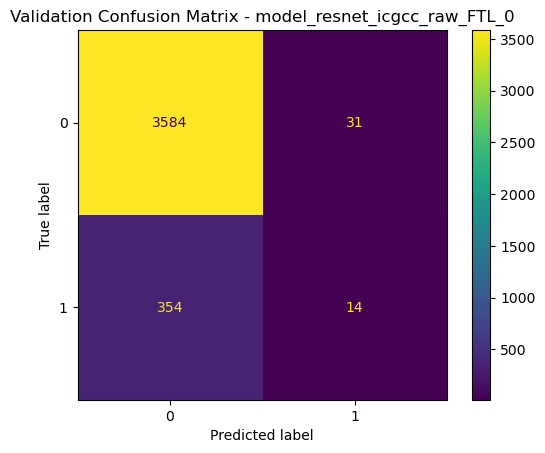

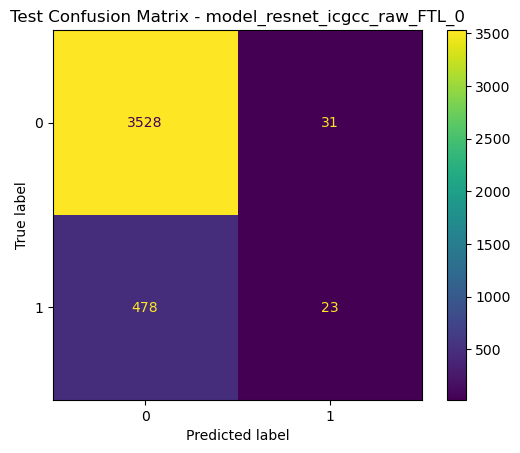

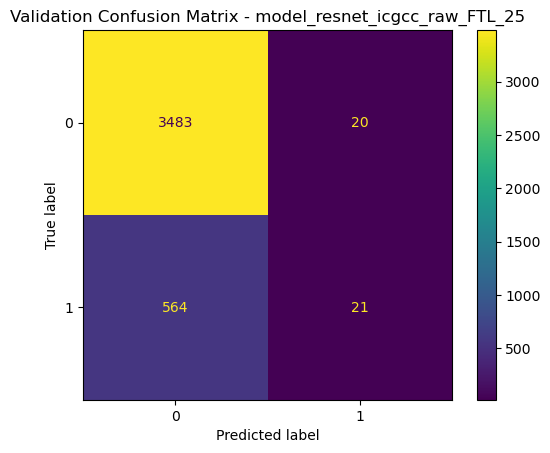

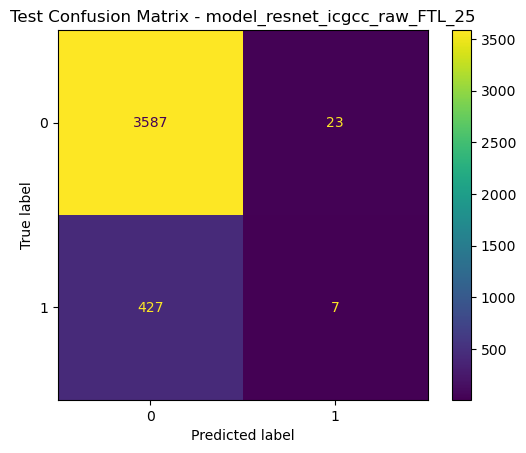

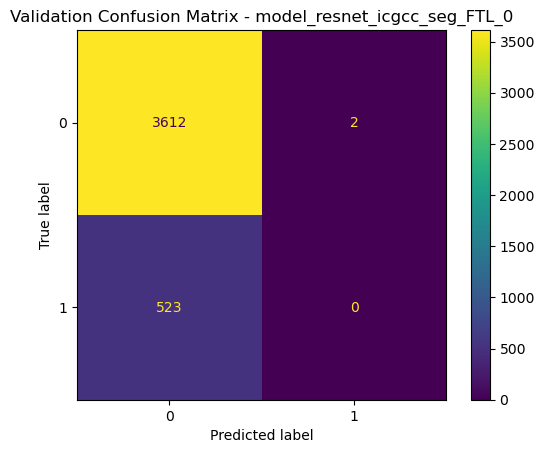

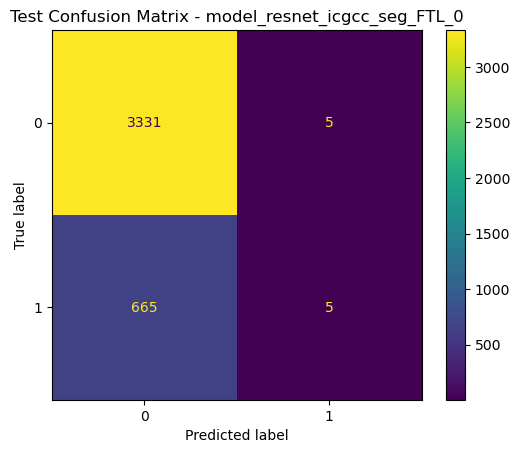

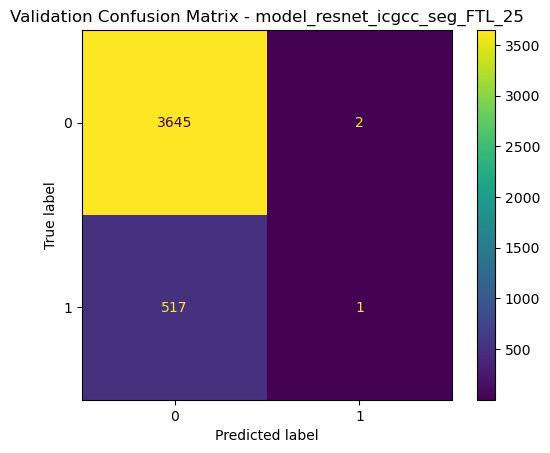

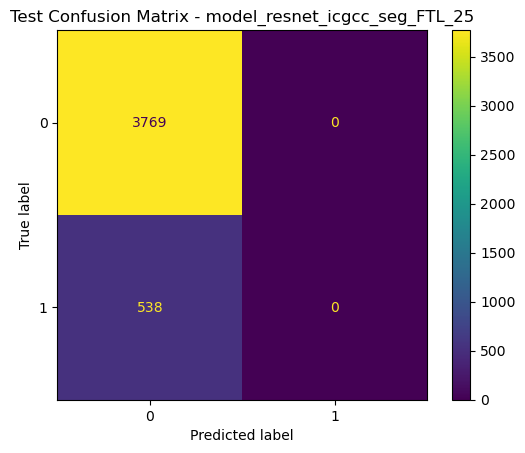


=== Summary of Test Accuracies ===
                         dataset  best_k_numeric_ids  \
0   model_resnet_icgcc_raw_FTL_0                  14   
1  model_resnet_icgcc_raw_FTL_25                  18   
2   model_resnet_icgcc_seg_FTL_0                  16   
3  model_resnet_icgcc_seg_FTL_25                  20   

   test_accuracy_numeric_ids  
0                   0.874631  
1                   0.888724  
2                   0.832751  
3                   0.875087  


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results = []

for path in folders:
    df = pd.read_csv(path + filename)

    # ----------------------------
    # TASK 1: ID classification
    # ----------------------------
    df['ggrade'] = df['ggrade'].fillna(0)

    # Step 1: Split based on unique numeric_ids
    unique_ids = df['numeric_ids'].unique()
    train_ids, temp_ids = train_test_split(unique_ids, test_size=0.4, random_state=42)
    val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

    # Step 2: Filter DataFrame based on splits
    df_train = df[df['numeric_ids'].isin(train_ids)]
    df_val = df[df['numeric_ids'].isin(val_ids)]
    df_test = df[df['numeric_ids'].isin(test_ids)]

    # Step 3: Prepare features and labels
    def prepare_xy(df_subset):
        X = np.array(list(zip(df_subset['reduced_embeddings_x'], df_subset['reduced_embeddings_y'])))
        y = df_subset['ggrade'].values
        return X, y

    X_train, y_id_train = prepare_xy(df_train)
    X_val, y_id_val = prepare_xy(df_val)
    X_test, y_id_test = prepare_xy(df_test)

    # Step 4: Best k search (ID)
    best_acc_id, best_k_id = 0, 1
    for k in range(1, 21):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_id_train)
        acc = knn.score(X_val, y_id_val)
        if acc > best_acc_id:
            best_acc_id = acc
            best_k_id = k
            best_knn_id = knn

    test_acc_id = best_knn_id.score(X_test, y_id_test)

    # Store results
    results.append({
        'dataset': path.split('/')[-2],
        'best_k_numeric_ids': best_k_id,
        'test_accuracy_numeric_ids': test_acc_id,
    })

    # --- Confusion Matrix: Validation Set ---
    y_val_pred = best_knn_id.predict(X_val)
    cm_val = confusion_matrix(y_id_val, y_val_pred)
    disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val)
    disp_val.plot()
    plt.title(f'Validation Confusion Matrix - {path.split("/")[-2]}')
    plt.show()
    
    # --- Confusion Matrix: Test Set ---
    y_test_pred = best_knn_id.predict(X_test)
    cm_test = confusion_matrix(y_id_test, y_test_pred)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
    disp_test.plot()
    plt.title(f'Test Confusion Matrix - {path.split("/")[-2]}')
    plt.show()

# Summary
results_df = pd.DataFrame(results)
print("\n=== Summary of Test Accuracies ===")
print(results_df)

In [15]:
results = []

for path in folders:
    df = pd.read_csv(path + filename)

    # ----------------------------
    # TASK 1: ID classification
    # ----------------------------
    reduced_embeddings = list(zip(df['reduced_embeddings_x'], df['reduced_embeddings_y']))
    X_id = np.array(reduced_embeddings)
    df['ggrade'] = df['ggrade'].fillna(0)
    y_id = df['ggrade'].values

    # Random 60/20/20 split
    X_train, X_temp, y_id_train, y_id_temp = train_test_split(
        X_id, y_id, test_size=0.4, random_state=42)
    X_val, X_test, y_id_val, y_id_test = train_test_split(
        X_temp, y_id_temp, test_size=0.5, random_state=42)

    # Best k search (ID)
    best_acc_id, best_k_id = 0, 1
    for k in range(1, 21):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_id_train)
        acc = knn.score(X_val, y_id_val)
        if acc > best_acc_id:
            best_acc_id = acc
            best_k_id = k
            best_knn_id = knn

    test_acc_id = best_knn_id.score(X_test, y_id_test)

    # Store results
    results.append({
        'dataset': path.split('/')[-2],
        'best_k_numeric_ids': best_k_id,
        'test_accuracy_numeric_ids': test_acc_id,
    })

# Summary
results_df = pd.DataFrame(results)
print("\n=== Summary of Test Accuracies ===")
print(results_df)



=== Summary of Test Accuracies ===
                         dataset  best_k_numeric_ids  \
0   model_resnet_icgcc_raw_FTL_0                  10   
1  model_resnet_icgcc_raw_FTL_25                  20   
2   model_resnet_icgcc_seg_FTL_0                  19   
3  model_resnet_icgcc_seg_FTL_25                  17   

   test_accuracy_numeric_ids  
0                    0.88875  
1                    0.87950  
2                    0.88225  
3                    0.88125  


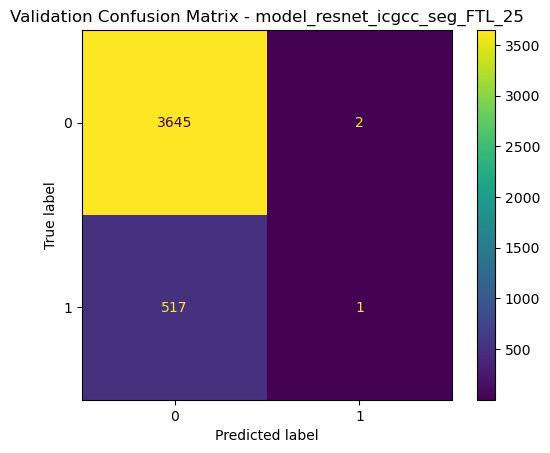

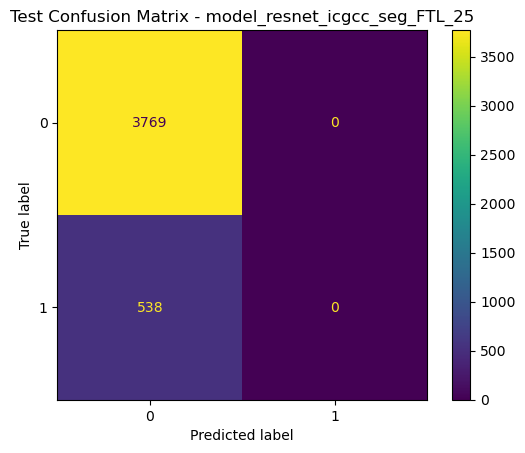

In [10]:
results = []

for path in folders:
    df = pd.read_csv(path + filename)

    # Filter ggrade values (1-4)
    # df_g = df[df['relapse_values'].isin([1, 2, 3, 4])].copy()

    # Only use these specific IDs
    # unique_ids = [1, 3, 7, 9]
    # df_g = df_g[df_g['numeric_ids'].isin(unique_ids)]

    # Define train/val/test splits as requested
    splits = []
    for test_id in unique_ids:
        remaining = [i for i in unique_ids if i != test_id]
        for val_id in remaining:
            train_ids = [i for i in remaining if i != val_id]
            splits.append({
                'train_ids': train_ids,
                'val_id': val_id,
                'test_id': test_id
            })

    # Run the k-NN classifier for each split
    for s in splits:
        train_df = df[df['numeric_ids'].isin(s['train_ids'])]
        val_df = df[df['numeric_ids'] == s['val_id']]
        test_df = df[df['numeric_ids'] == s['test_id']]

        # Skip empty splits
        if train_df.empty or val_df.empty or test_df.empty:
            continue

        # Prepare input and labels
        def get_xy(d):
            d['ggrade'] = d['ggrade'].fillna(0)
            X = np.array(list(zip(d['reduced_embeddings_x'], d['reduced_embeddings_y'])))
            y = d['ggrade'].values
            return X, y

        X_train, y_train = get_xy(train_df)
        X_val, y_val = get_xy(val_df)
        X_test, y_test = get_xy(test_df)

        # Find best k on validation set
        best_acc, best_k = 0, 1
        for k in range(1, 21):
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train, y_train)
            acc = knn.score(X_val, y_val)
            if acc > best_acc:
                best_acc = acc
                best_k = k
                best_knn = knn

        # Evaluate on test set
        test_acc = best_knn.score(X_test, y_test)

        results.append({
            'dataset': path.split('/')[-2],
            'train_ids': s['train_ids'],
            'val_id': s['val_id'],
            'test_id': s['test_id'],
            'best_k': best_k,
            'val_accuracy': best_acc,
            'test_accuracy': test_acc
        })

# Results summary
results_df = pd.DataFrame(results)
print("\n=== ggrade Classification Results (Custom ID Splits) ===")
print(results_df)


/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_71492/1791768694.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['ggrade'] = d['ggrade'].fillna(0)
/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_71492/1791768694.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['ggrade'] = d['ggrade'].fillna(0)
/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_71492/1791768694.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi


=== ggrade Classification Results (Custom ID Splits) ===
                          dataset train_ids  val_id  test_id  best_k  \
0    model_resnet_icgcc_raw_FTL_0    [7, 9]       3        1       4   
1    model_resnet_icgcc_raw_FTL_0    [3, 9]       7        1       1   
2    model_resnet_icgcc_raw_FTL_0    [3, 7]       9        1      14   
3    model_resnet_icgcc_raw_FTL_0    [7, 9]       1        3       2   
4    model_resnet_icgcc_raw_FTL_0    [1, 9]       7        3       1   
5    model_resnet_icgcc_raw_FTL_0    [1, 7]       9        3       6   
6    model_resnet_icgcc_raw_FTL_0    [3, 9]       1        7       1   
7    model_resnet_icgcc_raw_FTL_0    [1, 9]       3        7       1   
8    model_resnet_icgcc_raw_FTL_0    [1, 3]       9        7       1   
9    model_resnet_icgcc_raw_FTL_0    [3, 7]       1        9      16   
10   model_resnet_icgcc_raw_FTL_0    [1, 7]       3        9      14   
11   model_resnet_icgcc_raw_FTL_0    [1, 3]       7        9       1   
12  mo

/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_71492/1791768694.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['ggrade'] = d['ggrade'].fillna(0)
/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_71492/1791768694.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['ggrade'] = d['ggrade'].fillna(0)
/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_71492/1791768694.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

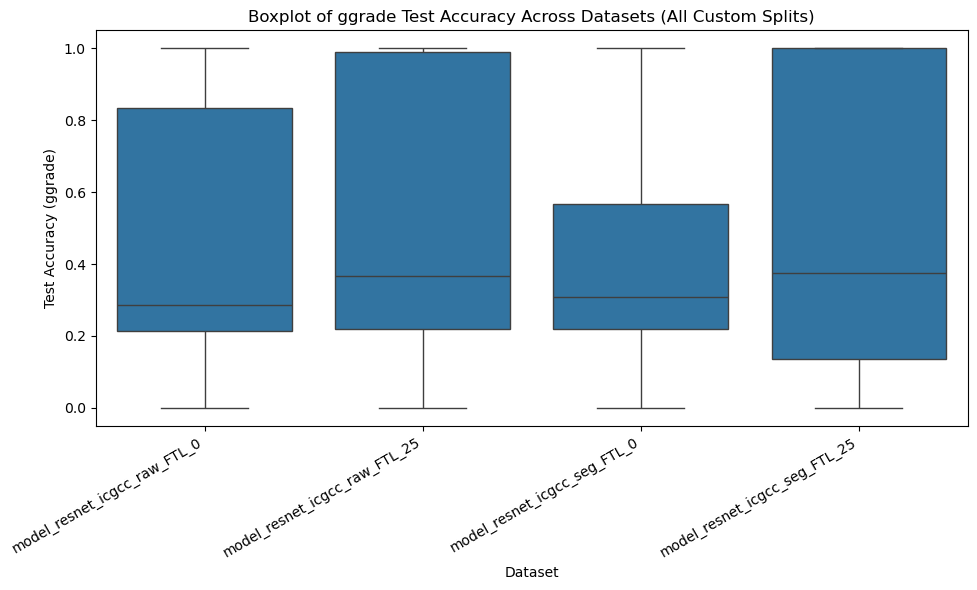

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure dataset column is string
results_df['dataset'] = results_df['dataset'].astype(str)

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, x='dataset', y='test_accuracy')

plt.title('Boxplot of ggrade Test Accuracy Across Datasets (All Custom Splits)')
plt.xlabel('Dataset')
plt.ylabel('Test Accuracy (ggrade)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [33]:
results = []

for path in folders:
    df = pd.read_csv(path + filename)

    # ----------------------------
    # TASK 1: ID classification
    # ----------------------------
    reduced_embeddings = list(zip(df['reduced_embeddings_x'], df['reduced_embeddings_y']))
    X_id = np.array(reduced_embeddings)
    y_id = df['numeric_ids'].values

    # Random 60/20/20 split
    X_train, X_temp, y_id_train, y_id_temp = train_test_split(
        X_id, y_id, test_size=0.4, random_state=42)
    X_val, X_test, y_id_val, y_id_test = train_test_split(
        X_temp, y_id_temp, test_size=0.5, random_state=42)

    # Best k search (ID)
    best_acc_id, best_k_id = 0, 1
    for k in range(1, 21):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_id_train)
        acc = knn.score(X_val, y_id_val)
        if acc > best_acc_id:
            best_acc_id = acc
            best_k_id = k
            best_knn_id = knn

    test_acc_id = best_knn_id.score(X_test, y_id_test)

    # ----------------------------
    # TASK 2: ggrade classification with permutations
    # ----------------------------
    df_g = df[df['ggrade'].isin([1, 2, 3, 4])].copy()
    unique_ids = df_g['numeric_ids'].unique()

    # Only consider permutations of 3 distinct IDs
    if len(unique_ids) < 3:
        print(f"Skipping {path}: not enough unique IDs for permutations.")
        continue

    for split_ids in permutations(unique_ids, 3):
        train_ids = [split_ids[0]]
        val_ids = [split_ids[1]]
        test_ids = [split_ids[2]]

        train_df = df_g[df_g['numeric_ids'].isin(train_ids)]
        val_df = df_g[df_g['numeric_ids'].isin(val_ids)]
        test_df = df_g[df_g['numeric_ids'].isin(test_ids)]

        if train_df.empty or val_df.empty or test_df.empty:
            continue  # Skip invalid splits

        # Prepare arrays
        def get_xy(d):
            X = np.array(list(zip(d['reduced_embeddings_x'], d['reduced_embeddings_y'])))
            y = d['ggrade'].values
            return X, y

        X_train_g, y_train_g = get_xy(train_df)
        X_val_g, y_val_g = get_xy(val_df)
        X_test_g, y_test_g = get_xy(test_df)

        # Best k search (ggrade)
        best_acc_grade, best_k_grade = 0, 1
        for k in range(1, 21):
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train_g, y_train_g)
            acc = knn.score(X_val_g, y_val_g)
            if acc > best_acc_grade:
                best_acc_grade = acc
                best_k_grade = k
                best_knn_grade = knn

        test_acc_grade = best_knn_grade.score(X_test_g, y_test_g)

        # Store results
        results.append({
            'dataset': path.split('/')[-2],
            'ggrade_split': f"{train_ids[0]}-{val_ids[0]}-{test_ids[0]}",
            'best_k_numeric_ids': best_k_id,
            'test_accuracy_numeric_ids': test_acc_id,
            'best_k_ggrade': best_k_grade,
            'test_accuracy_ggrade': test_acc_grade
        })

# Summary
results_df = pd.DataFrame(results)
print("\n=== Summary of Test Accuracies Across All Splits ===")
print(results_df)



=== Summary of Test Accuracies Across All Splits ===
                          dataset ggrade_split  best_k_numeric_ids  \
0     model_resnet_tcga_raw_FTL_0  1.0-7.0-9.0                   9   
1     model_resnet_tcga_raw_FTL_0  1.0-7.0-3.0                   9   
2     model_resnet_tcga_raw_FTL_0  1.0-9.0-7.0                   9   
3     model_resnet_tcga_raw_FTL_0  1.0-9.0-3.0                   9   
4     model_resnet_tcga_raw_FTL_0  1.0-3.0-7.0                   9   
..                            ...          ...                 ...   
91  model_resnet_tcga_seg_FTL_100  3.0-7.0-1.0                  20   
92  model_resnet_tcga_seg_FTL_100  3.0-9.0-7.0                  20   
93  model_resnet_tcga_seg_FTL_100  3.0-9.0-1.0                  20   
94  model_resnet_tcga_seg_FTL_100  3.0-1.0-7.0                  20   
95  model_resnet_tcga_seg_FTL_100  3.0-1.0-9.0                  20   

    test_accuracy_numeric_ids  best_k_ggrade  test_accuracy_ggrade  
0                    0.814862       

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out zero accuracies
filtered_df = results_df[results_df['test_accuracy_ggrade'] > 0.1].copy()
filtered_df['dataset'] = filtered_df['dataset'].astype(str)

# Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=filtered_df, x='dataset', y='test_accuracy_ggrade', inner='point')

plt.title('Distribution of ggrade Test Accuracy Across Datasets (Excluding 0.0)')
plt.xlabel('Dataset')
plt.ylabel('Test Accuracy (ggrade)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


KeyError: 'test_accuracy_ggrade'

In [31]:
results = []

for path in folders:
    df = pd.read_csv(path + filename)

    # ----------------------------
    # TASK 1: ID classification
    # ----------------------------
    reduced_embeddings = list(zip(df['reduced_embeddings_x'], df['reduced_embeddings_y']))
    X_id = np.array(reduced_embeddings)
    y_id = df['numeric_ids'].values

    # Random 60/20/20 split
    X_train, X_temp, y_id_train, y_id_temp = train_test_split(
        X_id, y_id, test_size=0.4, random_state=42)
    X_val, X_test, y_id_val, y_id_test = train_test_split(
        X_temp, y_id_temp, test_size=0.5, random_state=42)

    # Best k search (ID)
    best_acc_id, best_k_id = 0, 1
    for k in range(1, 21):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_id_train)
        acc = knn.score(X_val, y_id_val)
        if acc > best_acc_id:
            best_acc_id = acc
            best_k_id = k
            best_knn_id = knn

    test_acc_id = best_knn_id.score(X_test, y_id_test)

    # ----------------------------
    # TASK 2: ggrade classification
    # ----------------------------
    df_g = df[df['ggrade'].isin([1, 2, 3, 4])].copy()

    # Group by unique IDs and split IDs (not samples)
    unique_ids = df_g['numeric_ids'].unique()
    trainval_ids, test_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)
    train_ids, val_ids = train_test_split(trainval_ids, test_size=0.25, random_state=42)  # 60/20/20
    train_ids = [7,9]
    val_ids = [3]
    test_ids = [1]

    train_df = df_g[df_g['numeric_ids'].isin(train_ids)]
    val_df = df_g[df_g['numeric_ids'].isin(val_ids)]
    test_df = df_g[df_g['numeric_ids'].isin(test_ids)]

    # Prepare arrays
    def get_xy(d):
        X = np.array(list(zip(d['reduced_embeddings_x'], d['reduced_embeddings_y'])))
        y = d['ggrade'].values
        return X, y

    X_train_g, y_train_g = get_xy(train_df)
    X_val_g, y_val_g = get_xy(val_df)
    X_test_g, y_test_g = get_xy(test_df)

    # Best k search (ggrade)
    best_acc_grade, best_k_grade = 0, 1
    for k in range(1, 21):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_g, y_train_g)
        acc = knn.score(X_val_g, y_val_g)
        if acc > best_acc_grade:
            best_acc_grade = acc
            best_k_grade = k
            best_knn_grade = knn

    test_acc_grade = best_knn_grade.score(X_test_g, y_test_g)

    # Store results
    results.append({
        'dataset': path.split('/')[-2],
        'best_k_numeric_ids': best_k_id,
        'test_accuracy_numeric_ids': test_acc_id,
        'best_k_ggrade': best_k_grade,
        'test_accuracy_ggrade': test_acc_grade
    })

# Summary
results_df = pd.DataFrame(results)
print("\n=== Summary of Test Accuracies ===")
print(results_df)



=== Summary of Test Accuracies ===
                         dataset  best_k_numeric_ids  \
0    model_resnet_tcga_raw_FTL_0                   9   
1  model_resnet_tcga_raw_FTL_100                  16   
2    model_resnet_tcga_seg_FTL_0                  11   
3  model_resnet_tcga_seg_FTL_100                  20   

   test_accuracy_numeric_ids  best_k_ggrade  test_accuracy_ggrade  
0                   0.814862             19              0.232828  
1                   0.676703              2              0.446922  
2                   0.546445              2              0.550401  
3                   0.556054              2              0.693131  


In [15]:
print(trainval_ids)
print(test_ids)

[3. 7. 1.]
[9.]


In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define the dataset paths
folders = [
    '/Users/user/Documents/projects/GlandSeg/outputs/V2/o2_embeddings/tcga_ffpes/model_resnet_tcga_raw_FTL_0/',
    '/Users/user/Documents/projects/GlandSeg/outputs/V2/o2_embeddings/tcga_ffpes/model_resnet_tcga_raw_FTL_100/',
    '/Users/user/Documents/projects/GlandSeg/outputs/V2/o2_embeddings/tcga_ffpes/model_resnet_tcga_seg_FTL_0/',
    '/Users/user/Documents/projects/GlandSeg/outputs/V2/o2_embeddings/tcga_ffpes/model_resnet_tcga_seg_FTL_100/',
]
filename = 'reduced_embeddings_and_labels.csv'

results = []
apply_filter = False

for path in folders:
    df = pd.read_csv(path + filename)

    # Filter ggrade values (1-4 only)
    if apply_filter:
        df = df[df['ggrade'].isin([1, 2, 3, 4])]

    # Restore embedding structure
    reduced_embeddings = list(zip(df['reduced_embeddings_x'], df['reduced_embeddings_y']))
    cluster_labels = df['cluster_labels'].tolist()
    numeric_ids = df['numeric_ids'].tolist()
    ggrade = df['ggrade'].tolist()

    # Convert data to numpy arrays
    X = np.array(reduced_embeddings)
    y_id = np.array(numeric_ids)
    y_grade = np.array(ggrade)

    # Train/val/test split
    X_train, X_temp, y_id_train, y_id_temp, y_grade_train, y_grade_temp = train_test_split(
        X, y_id, y_grade, test_size=0.4, random_state=42)
    X_val, X_test, y_id_val, y_id_test, y_grade_val, y_grade_test = train_test_split(
        X_temp, y_id_temp, y_grade_temp, test_size=0.5, random_state=42)

    # Search for best k
    best_k_id = best_k_grade = 1
    best_acc_id = best_acc_grade = 0
    best_knn_id = best_knn_grade = None

    for k in range(1, 21):
        knn_id = KNeighborsClassifier(n_neighbors=k)
        knn_id.fit(X_train, y_id_train)
        acc_id = knn_id.score(X_val, y_id_val)
        if acc_id > best_acc_id:
            best_k_id = k
            best_acc_id = acc_id
            best_knn_id = knn_id

        knn_grade = KNeighborsClassifier(n_neighbors=k)
        knn_grade.fit(X_train, y_grade_train)
        acc_grade = knn_grade.score(X_val, y_grade_val)
        if acc_grade > best_acc_grade:
            best_k_grade = k
            best_acc_grade = acc_grade
            best_knn_grade = knn_grade

    # Evaluate on test set
    test_acc_id = best_knn_id.score(X_test, y_id_test)
    test_acc_grade = best_knn_grade.score(X_test, y_grade_test)

    results.append({
        'dataset': path.split('/')[-2],
        'best_k_numeric_ids': best_k_id,
        'test_accuracy_numeric_ids': test_acc_id,
        'best_k_ggrade': best_k_grade,
        'test_accuracy_ggrade': test_acc_grade
    })

# Print summary
results_df = pd.DataFrame(results)
print("\n=== Summary of Test Accuracies ===")
print(results_df)



=== Summary of Test Accuracies ===
                         dataset  best_k_numeric_ids  \
0    model_resnet_tcga_raw_FTL_0                   9   
1  model_resnet_tcga_raw_FTL_100                  16   
2    model_resnet_tcga_seg_FTL_0                  11   
3  model_resnet_tcga_seg_FTL_100                  20   

   test_accuracy_numeric_ids  best_k_ggrade  test_accuracy_ggrade  
0                   0.814862             14              0.764040  
1                   0.676703             14              0.683750  
2                   0.546445             12              0.689942  
3                   0.556054             19              0.703609  


In [ ]:
######################
## K-NN CLASSIFIERS ##
######################

"""
# Filter out entries where ggrade is not 1-4
valid_mask = np.isin(ggrade, [1, 2, 3, 4])
X = np.array(reduced_embeddings)[valid_mask]
y_id = np.array(numeric_ids)[valid_mask]
y_grade = np.array(ggrade)[valid_mask]

"""

# Convert data to numpy arrays ()
X = np.array(reduced_embeddings)
y_id = np.array(numeric_ids)
y_grade = np.array(ggrade)

# First split: train vs temp (60/40)
X_train, X_temp, y_id_train, y_id_temp, y_grade_train, y_grade_temp = train_test_split(
    X, y_id, y_grade, test_size=0.4, random_state=42)

# Second split: val vs test (20/20)
X_val, X_test, y_id_val, y_id_test, y_grade_val, y_grade_test = train_test_split(
    X_temp, y_id_temp, y_grade_temp, test_size=0.5, random_state=42)

best_k_id = 1
best_acc_id = 0
best_knn_id = None

best_k_grade = 1
best_acc_grade = 0
best_knn_grade = None

for k in range(1, 21):  # Try k from 1 to 20
    # numeric_ids
    knn_id = KNeighborsClassifier(n_neighbors=k)
    knn_id.fit(X_train, y_id_train)
    acc_id = knn_id.score(X_val, y_id_val)
    if acc_id > best_acc_id:
        best_k_id = k
        best_acc_id = acc_id
        best_knn_id = knn_id
    
    # ggrade
    knn_grade = KNeighborsClassifier(n_neighbors=k)
    knn_grade.fit(X_train, y_grade_train)
    acc_grade = knn_grade.score(X_val, y_grade_val)
    if acc_grade > best_acc_grade:
        best_k_grade = k
        best_acc_grade = acc_grade
        best_knn_grade = knn_grade

print(f"Best k for numeric_ids: {best_k_id}, Validation Accuracy: {best_acc_id:.2f}")
print(f"Best k for ggrade: {best_k_grade}, Validation Accuracy: {best_acc_grade:.2f}")

# Train k-NN classifier for numeric_ids
knn_id = KNeighborsClassifier(n_neighbors=3)
knn_id.fit(X_train, y_id_train)
y_id_pred = knn_id.predict(X_test)
print("ID Accuracy:", accuracy_score(y_id_test, y_id_pred))

# Train k-NN classifier for ggrade
knn_grade = KNeighborsClassifier(n_neighbors=3)
knn_grade.fit(X_train, y_grade_train)
y_grade_pred = knn_grade.predict(X_test)
print("Grade Accuracy:", accuracy_score(y_grade_test, y_grade_pred))

#
###

In [ ]:
##########################################
## VISUALISATIONS OF CONFUSION MATRICES ##
##########################################

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrices(knn, X_sets, y_sets, label_name):
    split_names = ['Train', 'Validation', 'Test']
    
    for X, y_true, name in zip(X_sets, y_sets, split_names):
        y_pred = knn.predict(X)
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues', values_format='d')
        plt.title(f'{label_name} Confusion Matrix ({name} Set)')
        plt.show()

# Re-train models (just in case)
knn_id = KNeighborsClassifier(n_neighbors=3)
knn_id.fit(X_train, y_id_train)

knn_grade = KNeighborsClassifier(n_neighbors=3)
knn_grade.fit(X_train, y_grade_train)

# Prepare data splits
X_sets = [X_train, X_val, X_test]
y_id_sets = [y_id_train, y_id_val, y_id_test]
y_grade_sets = [y_grade_train, y_grade_val, y_grade_test]

# Plot confusion matrices
plot_confusion_matrices(knn_id, X_sets, y_id_sets, "Numeric ID")
plot_confusion_matrices(knn_grade, X_sets, y_grade_sets, "Cancer Grade")

#
###